In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Linear Regression Model

In [10]:
class LinearRegression:
    def __init__(self):
        self.weights = np.random.randn(2)
        self.bias = np.random.randn()

    def predict(self, X):
        return X @ self.weights + self.bias

    def mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)
    
    def mae(self, y_true, y_pred):
        return np.mean(np.abs(y_true - y_pred))

    

## Hypothesis Set:
y = w1*x1 + w2*x2 + b

In [11]:
x1 = np.arange(-1, 1.001, 0.02)
x2 = np.arange(-1, 1.001, 0.02)

X1, X2 = np.meshgrid(x1, x2)

grid = np.column_stack((X1.ravel(), X2.ravel()))

print("Number of grid points:", len(grid))
print("Grid shape:", grid.shape)

Number of grid points: 10201
Grid shape: (10201, 2)


In [12]:
model = LinearRegression()

print("Weights:", model.weights)
print("Bias:", model.bias)

Weights: [ 0.49671415 -0.1382643 ]
Bias: 0.6476885381006925


In [13]:
predictions = model.predict(grid)

Z = predictions.reshape(X1.shape)

print("Prediction shape:", predictions.shape)
print("Grid output shape:", Z.shape)

Prediction shape: (10201,)
Grid output shape: (101, 101)


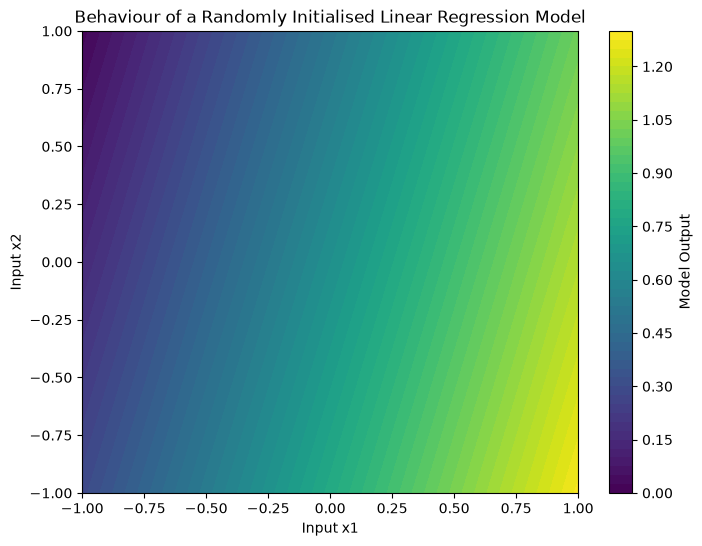

In [14]:
plt.figure(figsize=(8, 6))

plt.contourf(X1, X2, Z, levels=50)

plt.colorbar(label="Model Output")

plt.xlabel("Input x1")
plt.ylabel("Input x2")
plt.title("Behaviour of a Randomly Initialised Linear Regression Model")

plt.show()

In [15]:
print("Linear regression equation:")
print(
    f"y = {model.weights[0]:.4f} * x1 "
    f"+ {model.weights[1]:.4f} * x2 "
    f"+ {model.bias:.4f}"
)

Linear regression equation:
y = 0.4967 * x1 + -0.1383 * x2 + 0.6477


The UCI Bike Sharing Dataset is used as the real-world dataset for this project. The original hourly dataset contains 17,389 observations and includes weather, seasonal and bike rental information. The task is a regression problem: predicting the total number of rented bikes (`cnt`).

For this simple linear regression implementation, two numerical features are used: `temp` (normalised temperature) and `hum` (normalised humidity). The target is `cnt`, the total number of rented bikes.

A reproducible random sample of 10,000 observations is used so the model-family experiment produces the required 100 × 10,000 prediction matrix. The original dataset contains more observations, so this is a subset of the full dataset.

In [16]:
np.random.seed(42)

# Load the UCI Bike Sharing hourly dataset saved in the same folder as this notebook.
data = pd.read_csv("hour.csv")

print("Original dataset shape:", data.shape)

# Randomly select 10,000 observations for the model-family experiment.
data_sample = data.sample(n=10000, random_state=42)

# Use temperature and humidity as the two input features.
X = data_sample[["temp", "hum"]].to_numpy(dtype=float)

# Use total bike rental count as the regression target.
y = data_sample["cnt"].to_numpy(dtype=float)

print("Sample shape:", data_sample.shape)
print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Features: temp, hum")
print("Target: cnt")


Original dataset shape: (17379, 17)
Sample shape: (10000, 17)
Input shape: (10000, 2)
Target shape: (10000,)
Features: temp, hum
Target: cnt


## Dummy Function Test

Before training the real model, a simple dummy function is tested with the loaded dataset.
The dummy function always predicts zero for every observation. Its purpose is only to confirm that the data has the correct input/output format.

In [ ]:
def dummy_prediction(X):
    return np.zeros(len(X))

dummy_predictions = dummy_prediction(X)

print("Dummy prediction shape:", dummy_predictions.shape)
print("First 5 dummy predictions:", dummy_predictions[:5])
print("First 5 target values:", y[:5])

## Calculate Mean Squared Error (MSE)

In [17]:
predictions = model.predict(X)

loss = model.mse(y, predictions)

print("MSE:", loss)

MSE: 66724.96791632022


Generate Random Functions

In [18]:
models = []

for i in range(100):
    models.append(LinearRegression())

print("Number of models:", len(models))

Number of models: 100


Evaluate Random Functions

In [19]:
losses = []

for model in models:
    predictions = model.predict(X)
    loss = model.mse(y, predictions)
    losses.append(loss)

print("Best MSE:", min(losses))
print("Worst MSE:", max(losses))

best_index = np.argmin(losses)

best_model = models[best_index]

print("Best model weights:", best_model.weights)
print("Best model bias:", best_model.bias)
print("Best model MSE:", losses[best_index])

Best MSE: 65402.11416783049
Worst MSE: 68139.30585043954
Best model weights: [0.51378595 0.51504769]
Best model bias: 3.852731490654721
Best model MSE: 65402.11416783049


Comparing performance of the random functions

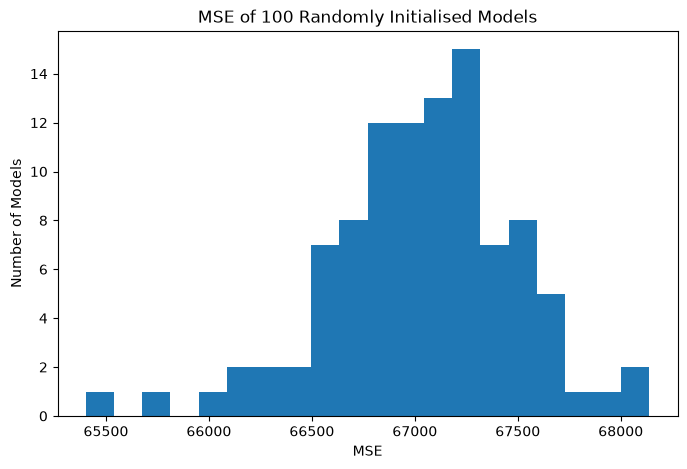

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(losses, bins=20)

plt.xlabel("MSE")
plt.ylabel("Number of Models")
plt.title("MSE of 100 Randomly Initialised Models")

plt.show()

Prediction Matrix

In [21]:
prediction_matrix = []

for model in models:
    predictions = model.predict(X)
    prediction_matrix.append(predictions)

prediction_matrix = np.array(prediction_matrix)

print("Prediction matrix shape:", prediction_matrix.shape)

Prediction matrix shape: (100, 10000)


## Prediction Behaviour

The prediction matrix can be used to investigate how different functions behave across the dataset.

The standard deviation of predictions at each observation measures how much the 100 functions disagree with each other.

A larger value indicates greater diversity in prediction behaviour.

In [22]:
prediction_std = np.std(prediction_matrix, axis=0)

print("Average prediction standard deviation:", np.mean(prediction_std))
print("Maximum prediction standard deviation:", np.max(prediction_std))

Average prediction standard deviation: 1.2328606821628865
Maximum prediction standard deviation: 1.4081430896922438


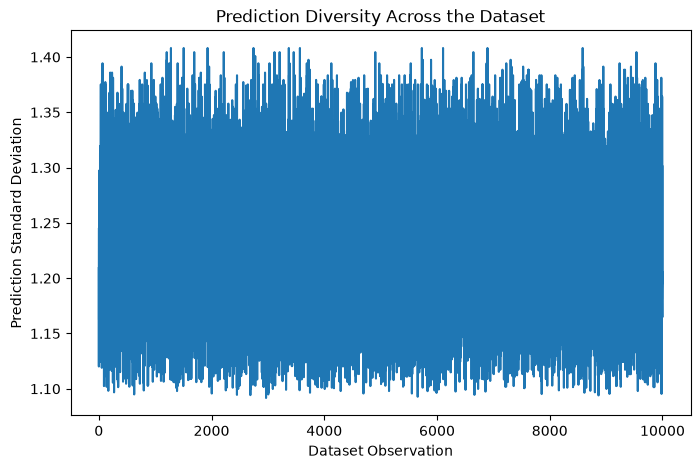

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(prediction_std)

plt.xlabel("Dataset Observation")
plt.ylabel("Prediction Standard Deviation")
plt.title("Prediction Diversity Across the Dataset")

plt.show()

## Increasing Model Family Diversity

The randomly generated functions can be made more diverse by increasing the amount of variation used when generating their parameters.

A larger standard deviation produces a wider range of weights and biases.

In [24]:
diverse_models = []

for i in range(100):
    new_model = LinearRegression()

    new_model.weights = np.random.normal(0, 2, 2)
    new_model.bias = np.random.normal(0, 2)

    diverse_models.append(new_model)

diverse_predictions = []

for model in diverse_models:
    diverse_predictions.append(model.predict(X))

diverse_predictions = np.array(diverse_predictions)

print("Diverse prediction matrix shape:", diverse_predictions.shape)
print(
    "Average prediction standard deviation:",
    np.mean(np.std(diverse_predictions, axis=0))
)

Diverse prediction matrix shape: (100, 10000)
Average prediction standard deviation: 2.71508295728854


# Model Training

The randomly generated functions showed that different parameter values produce different prediction behaviour.

The next step is to improve a randomly selected function.

The training process first uses a naive update strategy.

For each iteration:

1. Start with the current function.
2. Generate 100 nearby functions.
3. Evaluate their MSE.
4. Select the best nearby function.
5. Replace the current function if the new function performs better.
6. Repeat the process.

A nearby function is defined as one whose weights and bias are only slightly different from the current function.

In [25]:
current_model = LinearRegression()

current_predictions = current_model.predict(X)
current_loss = current_model.mse(y, current_predictions)

print("Starting MSE:", current_loss)

Starting MSE: 67037.53637042215


In [26]:
loss_history = []

for iteration in range(20):

    nearby_models = []

    for i in range(100):
        new_model = LinearRegression()

        new_model.weights = (
            current_model.weights
            + np.random.normal(0, 0.1, 2)
        )

        new_model.bias = (
            current_model.bias
            + np.random.normal(0, 0.1)
        )

        nearby_models.append(new_model)

    nearby_losses = []

    for model in nearby_models:
        predictions = model.predict(X)
        loss = model.mse(y, predictions)
        nearby_losses.append(loss)

    best_nearby_index = np.argmin(nearby_losses)

    best_nearby_model = nearby_models[best_nearby_index]
    best_nearby_loss = nearby_losses[best_nearby_index]

    if best_nearby_loss < current_loss:
        current_model = best_nearby_model
        current_loss = best_nearby_loss

    loss_history.append(current_loss)

print("Final MSE:", current_loss)

Final MSE: 64675.398406306624


## Naive Training Progress

The MSE recorded during each iteration is plotted to determine whether the naive training process improves the model.

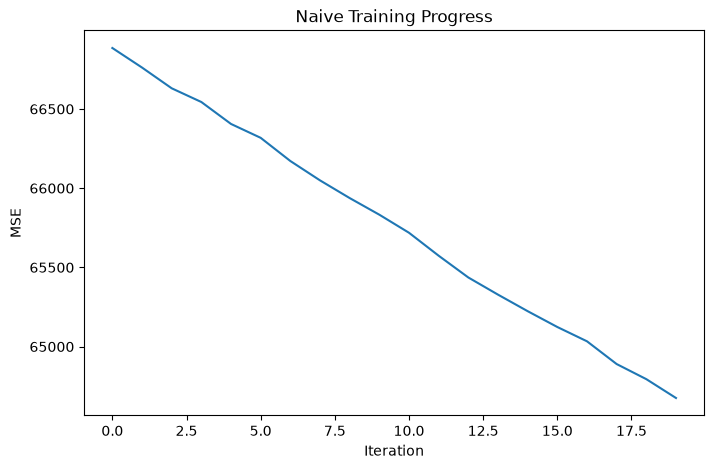

In [27]:
naive_loss_history = loss_history

plt.figure(figsize=(8, 5))

plt.plot(naive_loss_history)

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Naive Training Progress")

plt.show()

# Gradient Descent

The naive update randomly generates nearby functions and selects the best one.

Gradient descent provides a more systematic approach.

Instead of randomly changing the parameters, the gradients of the MSE loss are calculated to determine the direction in which the weights and bias should move.

The parameters are updated using:

parameter = parameter - learning_rate * gradient

The learning rate controls the size of each update.

In [28]:
def gradient_descent(model, X, y, learning_rate):

    predictions = model.predict(X)

    errors = predictions - y

    weight_gradient = (2 / len(X)) * (X.T @ errors)

    bias_gradient = (2 / len(X)) * np.sum(errors)

    model.weights = model.weights - learning_rate * weight_gradient

    model.bias = model.bias - learning_rate * bias_gradient

In [29]:
model = LinearRegression()

gradient_loss_history = []

learning_rate = 0.1

for iteration in range(1000):

    gradient_descent(model, X, y, learning_rate)

    predictions = model.predict(X)

    loss = model.mse(y, predictions)

    gradient_loss_history.append(loss)

print("Final MSE:", gradient_loss_history[-1])

Final MSE: 24339.224733988307


## Gradient Descent Training Progress

The MSE is plotted over the training iterations to observe how gradient descent reduces the loss.

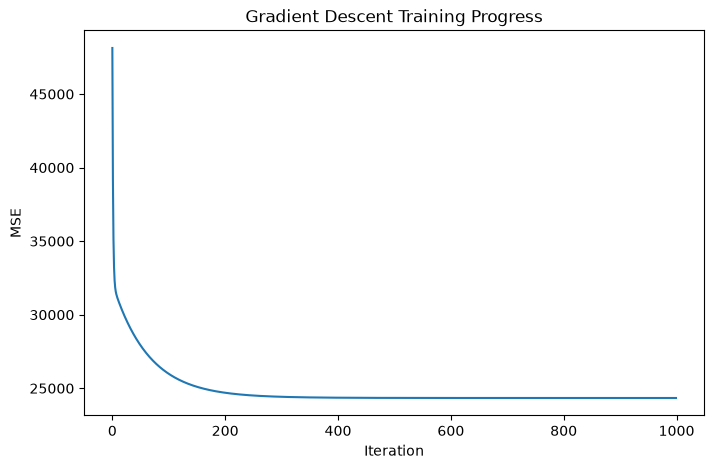

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(gradient_loss_history)

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Gradient Descent Training Progress")

plt.show()

## Naive Training vs Gradient Descent

The two training approaches are compared.

Naive training searches for improvements by randomly generating nearby functions.

Gradient descent uses the mathematical gradient of the loss to determine how the parameters should be updated.

In [31]:
print("Naive final MSE:", naive_loss_history[-1])
print("Gradient descent final MSE:", gradient_loss_history[-1])

Naive final MSE: 64675.398406306624
Gradient descent final MSE: 24339.224733988307


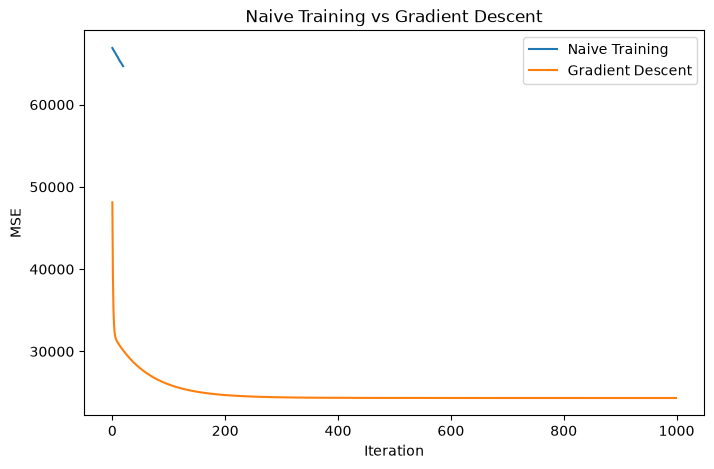

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(naive_loss_history, label="Naive Training")
plt.plot(gradient_loss_history, label="Gradient Descent")

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Naive Training vs Gradient Descent")

plt.legend()

plt.show()

# Train/Test Evaluation

The dataset is divided into training and testing data.

The model is trained using the training data.

The testing data is kept separate and is only used after training to evaluate how well the model generalises to unseen observations.

In [33]:
np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
y_train = y[train_indices]

X_test = X[test_indices]
y_test = y[test_indices]

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

Training examples: 8000
Testing examples: 2000


In [34]:
model = LinearRegression()

loss_history = []

learning_rate = 0.1

for iteration in range(1000):

    gradient_descent(model, X_train, y_train, learning_rate)

    predictions = model.predict(X_train)

    loss = model.mse(y_train, predictions)

    loss_history.append(loss)

print("Final training MSE:", loss_history[-1])

Final training MSE: 24276.404602382503


## Test Evaluation

The trained model is evaluated on both the training and testing data.

The test MSE provides evidence of how well the model generalises to data that was not used during training.

In [35]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_mse = model.mse(y_train, train_predictions)
test_mse = model.mse(y_test, test_predictions)

print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)

Training MSE: 24276.404602382503
Testing MSE: 24604.320816011725


# Alternative Loss Function — MAE

Mean Absolute Error (MAE) is considered as an alternative to MSE.

MAE calculates the average absolute difference between the true values and predictions.

MSE gives greater importance to large errors because the errors are squared.

MAE does not square the errors, so it is less affected by large individual errors.

MSE is retained as the main training loss because its smooth mathematical form allows the gradients used by gradient descent to be calculated directly.

In [36]:
test_mse = model.mse(y_test, test_predictions)
test_mae = model.mae(y_test, test_predictions)

print("Test MSE:", test_mse)
print("Test MAE:", test_mae)

Test MSE: 24604.320816011725
Test MAE: 117.0339321777496


# Final Model

The final trained parameters and equation are displayed below.

In [37]:
print("Final linear regression equation:")

print(
    f"y = {model.weights[0]:.4f} * x1 "
    f"+ {model.weights[1]:.4f} * x2 "
    f"+ {model.bias:.4f}"
)

print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)
print("Testing MAE:", test_mae)

Final linear regression equation:
y = 358.2112 * x1 + -272.3039 * x2 + 180.0618
Training MSE: 24276.404602382503
Testing MSE: 24604.320816011725
Testing MAE: 117.0339321777496


## Final Model Behaviour

The final trained model is visualised using the same input grid used to visualise the randomly initialised model.

This allows the behaviour of the random and trained hypotheses to be compared.

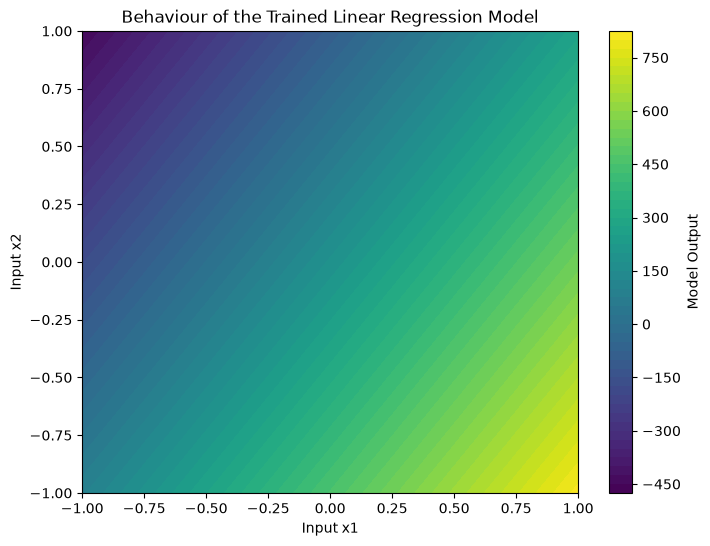

In [38]:
predictions = model.predict(grid)

Z = predictions.reshape(X1.shape)

plt.figure(figsize=(8, 6))

plt.contourf(X1, X2, Z, levels=50)

plt.colorbar(label="Model Output")

plt.xlabel("Input x1")
plt.ylabel("Input x2")
plt.title("Behaviour of the Trained Linear Regression Model")

plt.show()

# Reflection

This project implemented and studied a simple linear regression model from scratch.

The hypothesis family consisted of linear functions of the form:

y = w1*x1 + w2*x2 + b

The parameters w1, w2 and b define each member of the hypothesis family. 100 randomly initialised functions were generated and evaluated using Mean Squared Error.

A 100 × 10,000 prediction matrix was created to investigate the differences in prediction behaviour between the functions.

A naive training process was then implemented. For each iteration, 100 nearby functions were generated by making small changes to the current weights and bias. The function with the lowest MSE was selected when it improved upon the current function.

The naive approach was then improved using gradient descent. Gradient descent calculates the gradients of the MSE with respect to the model's weights and bias and updates the parameters in the direction that reduces the loss.

The model was evaluated using separate training and testing data. MSE was used as the primary loss and MAE was investigated as an alternative evaluation criterion.

A limitation of linear regression is that it can only represent linear relationships. A neural network would be able to model more complex non-linear relationships and could therefore be investigated as a modern alternative.